# Proyecto C: Audio Source Separation via NMF
## Fase 4: Bucle de Entrenamiento, Experimentos y Visualización
**Responsable:** Julio Alfonso Rangel Ortiz (Integrante 4)
**Materia:** Optimización Matemática

Este notebook integra el pipeline DSP y el motor matemático BCGD para ejecutar los entrenamientos sistemáticos del modelo. 

**Objetivos de esta sección:**
1. Iterar sobre diferentes hiperparámetros (rango $k$ entre 5 y 20).
2. Implementar políticas de control de ejecución (detención por `NaN` o estancamiento de pérdida).
3. Generar gráficos comparativos de rendimiento y visualizaciones espectrales.

### 1. Configuración del Entorno y Estilo Visual
Importamos las librerías necesarias, conectamos el módulo de optimización y establecemos una plantilla visual minimalista y profesional para garantizar que todas las gráficas generadas tengan un formato unificado.

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'BCGD')))
from algoritmoBCGDUnificado import bcgd_matrix_factorization

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 11, 'axes.titlesize': 14,
    'axes.labelsize': 12, 'lines.linewidth': 2, 'lines.markersize': 6,
    'figure.figsize': (10, 6), 'figure.autolayout': True 
})
print("Librerías importadas y estilo visual configurado correctamente.")

Librerías importadas y estilo visual configurado correctamente.


### 2. Implementación de Políticas de Control
El optimizador Nesterov es sensible a divergencias con datos de alta dimensionalidad. Para evitar ejecuciones fallidas, envolvemos la función `bcgd_matrix_factorization` con dos validaciones de seguridad:
* **Control de Divergencia:** Detiene el entrenamiento si la pérdida se vuelve `NaN` o infinita.
* **Control de Estancamiento:** Detiene el bucle si la mejora en la función de pérdida es imperceptible (menor a $10^{-4}$) durante 5 iteraciones consecutivas.

In [17]:
def entrenar_con_controles(X, k, steps, alphaW, alphaH, method):
    """
    Envoltorio para la función de optimización que añade políticas de control
    (Detección de divergencia y estancamiento).
    """
    # 1. Ejecutamos el algoritmo original de tu compañero
    # Le pasamos lambd=0.0 como se indicó en las instrucciones
    W, H, loss_history = bcgd_matrix_factorization(
        X=X, k=k, steps=steps, alphaW=alphaW, alphaH=alphaH, 
        method=method, lambd=0.0
    )
    
    # 2. Política de Control a posteriori (Revisión del historial)
    loss_filtrada = []
    motivo_parada = "Convergencia normal (Max steps)"
    
    for i, loss in enumerate(loss_history):
        # Control 1: Divergencia (NaN o Infinito)
        if np.isnan(loss) or np.isinf(loss):
            print(f"  [!] {method.upper()}: Divergencia detectada (NaN) en iteración {i}.")
            motivo_parada = "Divergencia (NaN)"
            break
            
        # Control 2: Estancamiento 
        # (Si la mejora es menor a 1e-4 durante 5 iteraciones seguidas)
        if i > 5:
            mejoras_recientes = [abs(loss_history[j] - loss_history[j-1]) for j in range(i-4, i+1)]
            if all(mejora < 1e-4 for mejora in mejoras_recientes):
                print(f"  [!] {method.upper()}: Estancamiento detectado en iteración {i}.")
                motivo_parada = "Estancamiento"
                loss_filtrada.append(loss)
                break
                
        loss_filtrada.append(loss)
        
    return W, H, loss_filtrada, motivo_parada

print("Función de entrenamiento con controles definida.")

Función de entrenamiento con controles definida.


### 3. Bucle de Entrenamiento y Experimentación
Ejecutamos el modelo probando distintos números de componentes base ($k \in \{5, 10, 15, 20\}$) para los tres optimizadores: **Vanilla GD**, **Momentum** y **Nesterov**. 

*Nota:* Se ajusta la tasa de aprendizaje ($\alpha$) a $10^{-5}$ específicamente para Nesterov, previniendo la inestabilidad reportada en las pruebas numéricas.

In [18]:
# --- 1. CARGA DE DATOS REALES ---
print("Cargando matriz de datos reales (Espectrograma MUSAN)...")

# Apuntamos exactamente al archivo que tienes en tu carpeta
ruta_datos = "/Users/julio/Documents/proyecto_nmf_audio/data/processed/X_train.npy" 

# Cargamos el archivo
X_train = np.load(ruta_datos)
print(f"¡Datos reales cargados con éxito! Forma de la matriz: {X_train.shape}")

# --- 2. CONFIGURACIÓN DE HIPERPARÁMETROS ---
k_values = [5, 10, 15, 20] 
metodos = ['gd', 'momentum', 'nesterov']
# Reducimos un poco las iteraciones máximas a 150 para que no tarde 
# tanto tu computadora ahora que los datos son masivos.
iteraciones_maximas = 150 

resultados_experimentos = {}

# --- 3. BUCLE DE ENTRENAMIENTO ---
print("\nIniciando batería de experimentos con AUDIO REAL...")
for k in k_values:
    print(f"\n--- Evaluando k = {k} ---")
    resultados_experimentos[k] = {}
    
    for metodo in metodos:
        # Ajuste de learning rate específico para Nesterov
        alpha_actual = 1e-5 if metodo == 'nesterov' else 1e-3
        
        print(f"Entrenando {metodo.upper()} (alpha={alpha_actual})... ", end="")
        
        W, H, loss_hist, motivo = entrenar_con_controles(
            X=X_train, k=k, steps=iteraciones_maximas, 
            alphaW=alpha_actual, alphaH=alpha_actual, method=metodo
        )
        
        resultados_experimentos[k][metodo] = {
            'W': W,
            'H': H,
            'loss_history': loss_hist,
            'status': motivo
        }
        print(f"[{motivo}]")

print("\n¡Todos los experimentos finalizaron con éxito!")

Cargando matriz de datos reales (Espectrograma MUSAN)...
¡Datos reales cargados con éxito! Forma de la matriz: (1025, 886)

Iniciando batería de experimentos con AUDIO REAL...

--- Evaluando k = 5 ---
Entrenando GD (alpha=0.001)... [Convergencia normal (Max steps)]
Entrenando MOMENTUM (alpha=0.001)... [Convergencia normal (Max steps)]
Entrenando NESTEROV (alpha=1e-05)... [Convergencia normal (Max steps)]

--- Evaluando k = 10 ---
Entrenando GD (alpha=0.001)... [Convergencia normal (Max steps)]
Entrenando MOMENTUM (alpha=0.001)... [Convergencia normal (Max steps)]
Entrenando NESTEROV (alpha=1e-05)... [Convergencia normal (Max steps)]

--- Evaluando k = 15 ---
Entrenando GD (alpha=0.001)... [Convergencia normal (Max steps)]
Entrenando MOMENTUM (alpha=0.001)... [Convergencia normal (Max steps)]
Entrenando NESTEROV (alpha=1e-05)... [Convergencia normal (Max steps)]

--- Evaluando k = 20 ---
Entrenando GD (alpha=0.001)... [Convergencia normal (Max steps)]
Entrenando MOMENTUM (alpha=0.001)..

### 4. Visualización Comparativa de Optimizadores
Para justificar la elección del algoritmo, comparamos la evolución de la función de pérdida durante el entrenamiento. Se utiliza una **escala logarítmica** en el eje Y para apreciar mejor las diferencias sutiles en las etapas finales de convergencia.

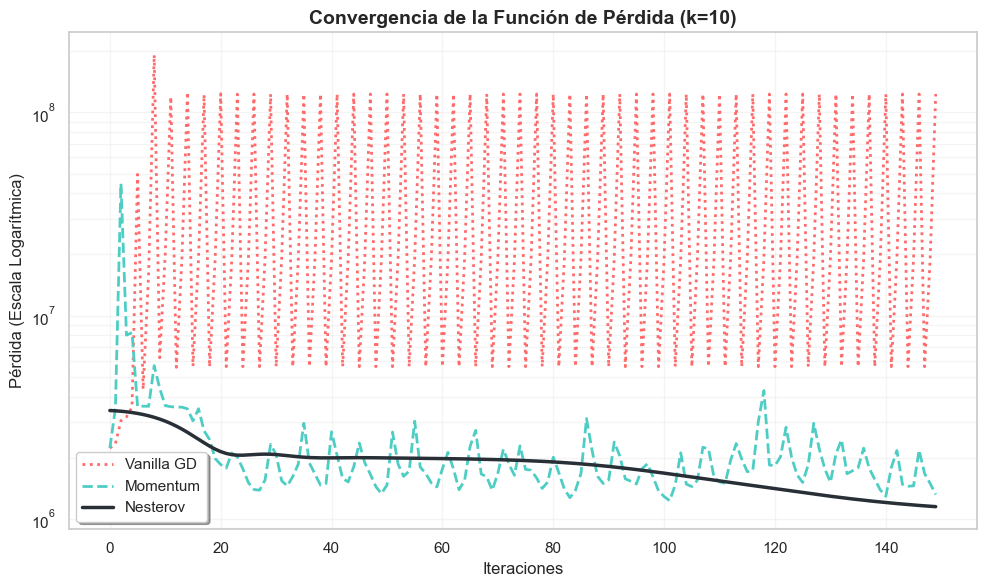

In [19]:
# --- GRÁFICO 1: PÉRDIDA VS ITERACIÓN ---
# Elegimos k=10 como caso representativo para la gráfica
k_viz = 10

plt.figure(figsize=(10, 6))

# Trazamos las curvas de los 3 métodos
plt.plot(resultados_experimentos[k_viz]['gd']['loss_history'], 
         label='Vanilla GD', linestyle=':', color='#FF6B6B')
plt.plot(resultados_experimentos[k_viz]['momentum']['loss_history'], 
         label='Momentum', linestyle='--', color='#4ECDC4')
plt.plot(resultados_experimentos[k_viz]['nesterov']['loss_history'], 
         label='Nesterov', linewidth=2.5, color='#292F36')

plt.yscale('log') # Escala logarítmica crucial para ver detalles
plt.title(f'Convergencia de la Función de Pérdida (k={k_viz})', fontweight='bold')
plt.xlabel('Iteraciones')
plt.ylabel('Pérdida (Escala Logarítmica)')
plt.legend(frameon=True, shadow=True)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

### 5. Interpretación Semántica: Bases y Activaciones
El objetivo de NMF es encontrar una representación por partes. 
* La matriz **$W$ (Bases Espectrales)** representa los "patrones de frecuencia" o instrumentos/voces individuales descubiertos en el audio.
* La matriz **$H$ (Activaciones Temporales)** indica "cuándo" y con qué "intensidad" suena cada uno de esos patrones a lo largo del tiempo.

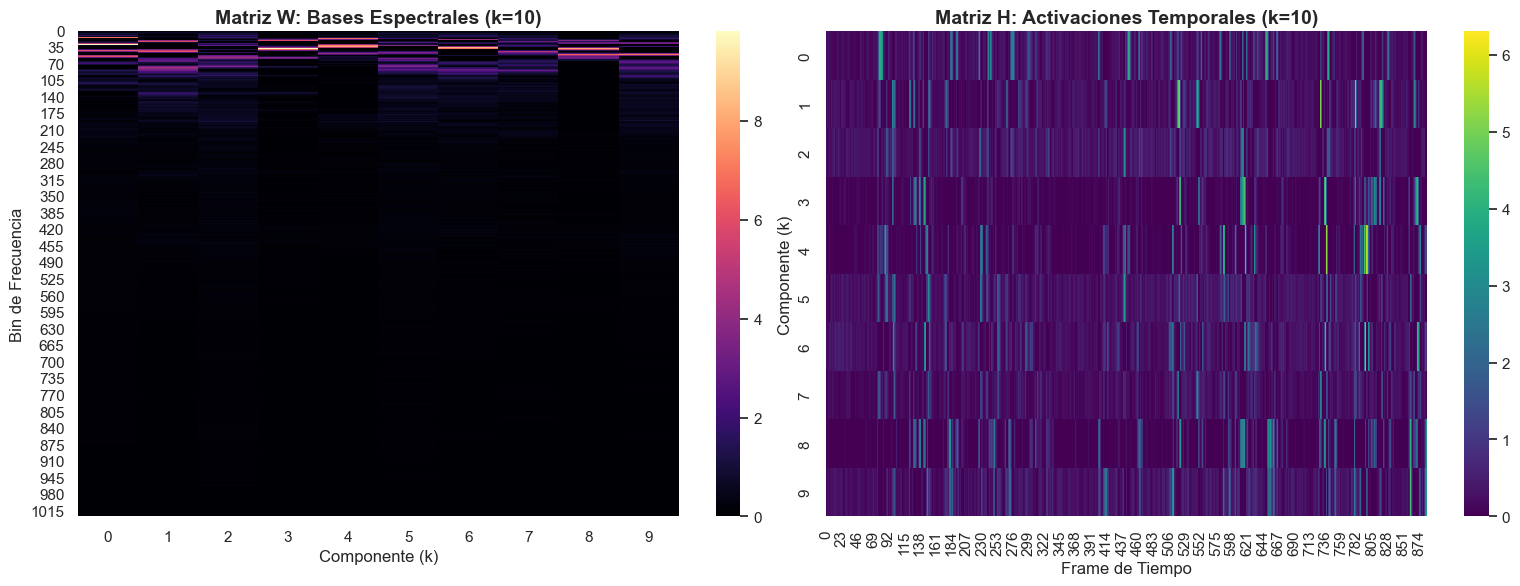

In [20]:
# --- GRÁFICO 2 y 3: VISUALIZACIÓN DE MATRICES W y H ---
# Extraemos el mejor modelo (Nesterov)
W_best = resultados_experimentos[k_viz]['nesterov']['W']
H_best = resultados_experimentos[k_viz]['nesterov']['H']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap para las Bases Espectrales (W)
sns.heatmap(W_best, ax=ax1, cmap="magma", cbar=True)
ax1.set_title(f'Matriz W: Bases Espectrales (k={k_viz})', fontweight='bold')
ax1.set_xlabel('Componente (k)')
ax1.set_ylabel('Bin de Frecuencia')

# Heatmap para las Activaciones Temporales (H)
sns.heatmap(H_best, ax=ax2, cmap="viridis", cbar=True)
ax2.set_title(f'Matriz H: Activaciones Temporales (k={k_viz})', fontweight='bold')
ax2.set_xlabel('Frame de Tiempo')
ax2.set_ylabel('Componente (k)')

plt.tight_layout()
plt.show()

### 6. Análisis de Desempeño vs. Complejidad ($k$)
Evaluamos cómo se comporta la pérdida final al aumentar la dimensionalidad $k$. A mayor $k$, el modelo tiene más flexibilidad para reconstruir el audio, pero corremos el riesgo de sobreajuste (aprender ruido).

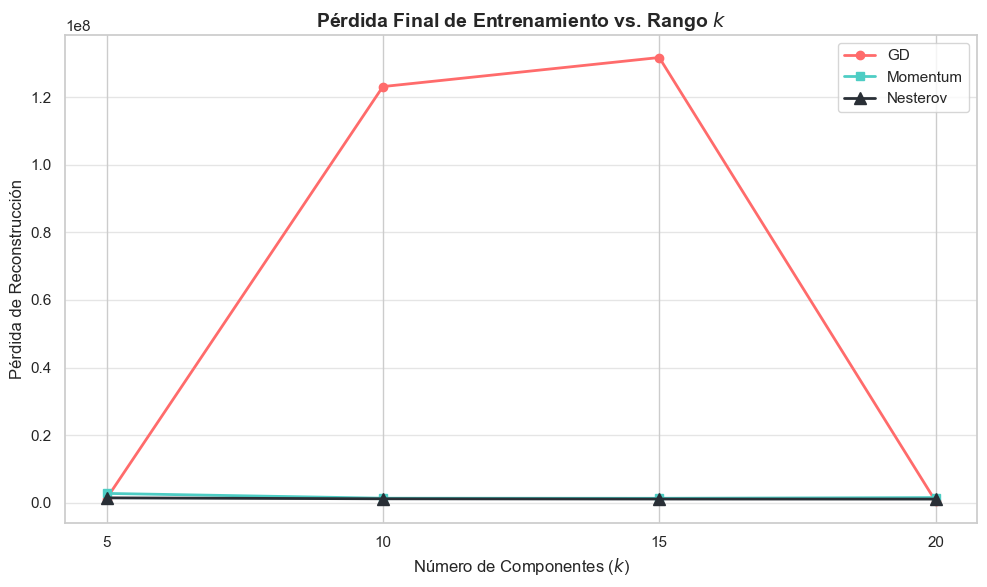

In [21]:
# --- GRÁFICO 4: MÉTRICA FINAL VS RANGO K ---
k_list = sorted(list(resultados_experimentos.keys()))
loss_final_gd = [resultados_experimentos[k]['gd']['loss_history'][-1] for k in k_list]
loss_final_mom = [resultados_experimentos[k]['momentum']['loss_history'][-1] for k in k_list]
loss_final_nes = [resultados_experimentos[k]['nesterov']['loss_history'][-1] for k in k_list]

plt.figure(figsize=(10, 6))
plt.plot(k_list, loss_final_gd, marker='o', label='GD', color='#FF6B6B')
plt.plot(k_list, loss_final_mom, marker='s', label='Momentum', color='#4ECDC4')
plt.plot(k_list, loss_final_nes, marker='^', label='Nesterov', color='#292F36', markersize=8)

plt.title('Pérdida Final de Entrenamiento vs. Rango $k$', fontweight='bold')
plt.xlabel('Número de Componentes ($k$)')
plt.ylabel('Pérdida de Reconstrucción')
plt.xticks(k_list)
plt.legend()
plt.grid(axis='y', alpha=0.5)
plt.show()